# CASE 01 Python EDA: Retail Customer & Revenue

## tl;dr

이 노트북은 검증이 끝난 원본 Excel을 공통 준비 모듈로 다시 읽어, 매출 추세·국가·상품·고객·취소/반품 구조를 탐색합니다. 아래 요약은 노트북 실행 결과로 생성되며, 데이터에 없는 비용·마진·광고·고객 속성에 관한 결론은 내리지 않습니다.

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

CASE_NAME = "01_retail_customer_analytics"
case_dir_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "cases" / CASE_NAME,
]
case_dir = next(
    (path.resolve() for path in case_dir_candidates
     if (path / "data" / "raw" / "online_retail_II.xlsx").exists()),
    None,
)
if case_dir is None:
    raise FileNotFoundError(
        "online_retail_II.xlsx를 찾지 못했습니다. 저장소 루트 또는 notebooks 폴더에서 실행하세요."
    )

sys.path.insert(0, str(case_dir / "src"))
from data_preparation import count_exact_duplicate_extras, load_and_prepare_retail_data

raw_path = case_dir / "data" / "raw" / "online_retail_II.xlsx"
figure_dir = case_dir / "evidence" / "eda_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

prepared = load_and_prepare_retail_data(raw_path)
retail_df = prepared.retail_df
sales_analysis_df = prepared.sales_analysis_df
customer_analysis_df = prepared.customer_analysis_df
returns_df = prepared.returns_df

for frame in (retail_df, sales_analysis_df, customer_analysis_df):
    frame["Invoice_Key"] = frame["Source_Sheet"] + "|" + frame["Invoice"]

gross_sales = sales_analysis_df["Total_Revenue"].sum()
observed_net_revenue = retail_df["Total_Revenue"].sum()
identified_sales = customer_analysis_df["Total_Revenue"].sum()
negative_transaction_value = -retail_df.loc[
    retail_df["Total_Revenue"].lt(0), "Total_Revenue"
].sum()

customer_summary = customer_analysis_df.groupby("Customer ID").agg(
    orders=("Invoice_Key", "nunique"),
    revenue=("Total_Revenue", "sum"),
    units=("Quantity", "sum"),
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),
)
customer_summary["average_order_value"] = (
    customer_summary["revenue"] / customer_summary["orders"]
)
repeat_customer_rate = customer_summary["orders"].ge(2).mean()

country_summary = (
    sales_analysis_df.groupby("Country", dropna=False)
    .agg(
        revenue=("Total_Revenue", "sum"),
        orders=("Invoice_Key", "nunique"),
        units=("Quantity", "sum"),
    )
    .sort_values("revenue", ascending=False)
)
uk_revenue_share = country_summary.loc["United Kingdom", "revenue"] / gross_sales

display(Markdown(
    f''' 
**실행 요약**

- 분석 기간: **{retail_df['InvoiceDate'].min():%Y-%m-%d} ~ {retail_df['InvoiceDate'].max():%Y-%m-%d}**
- 정상 양수 매출: **£{gross_sales:,.0f}**, 관측 순거래액: **£{observed_net_revenue:,.0f}**
- 정상 매출 중 고객 ID 식별 비중: **{identified_sales / gross_sales:.1%}**
- 식별 고객 **{len(customer_summary):,}명** 중 2회 이상 구매 고객 비중: **{repeat_customer_rate:.1%}**
- 영국의 정상 매출 비중: **{uk_revenue_share:.1%}**

`관측 순거래액`은 raw의 `Quantity × Price` 합계입니다. 환율·세금·배송비·원가가 없으므로 회계 매출이나 이익으로 해석하지 않습니다.
'''
))

 
**실행 요약**

- 분석 기간: **2009-12-01 ~ 2011-12-09**
- 정상 양수 매출: **£20,972,595**, 관측 순거래액: **£19,287,251**
- 정상 매출 중 고객 ID 식별 비중: **84.6%**
- 식별 고객 **5,878명** 중 2회 이상 구매 고객 비중: **72.8%**
- 영국의 정상 매출 비중: **85.2%**

`관측 순거래액`은 raw의 `Quantity × Price` 합계입니다. 환율·세금·배송비·원가가 없으므로 회계 매출이나 이익으로 해석하지 않습니다.


## Context & Methods

### 분석 질문

관측 기간의 정상 양수 매출은 시기·국가·상품·고객별로 어떻게 분포하며, 취소·반품이 총거래액에 어느 정도 영향을 주는가?

### Key Assumptions

- `sales_analysis_df`: 고객 ID 결측 여부와 관계없이 취소·반품이 아니며 수량과 가격이 양수인 거래 라인입니다.
- `customer_analysis_df`: 정상 매출 중 고객 ID가 있는 거래만 포함합니다.
- `retail_df`: 취소·반품과 조정 거래를 보존하며 관측 순거래액 계산에 사용합니다.
- 송장 번호는 두 Excel 시트 사이에서 충돌할 가능성을 막기 위해 `Source_Sheet + Invoice`로 식별합니다.
- 고유 거래 라인 ID가 없으므로 중복 후보 34,335행을 임의 제거하지 않습니다. 금액 지표는 이 계약의 영향을 받을 수 있습니다.
- 2009년 12월과 2011년 12월은 부분 월이므로 완전한 월과 직접 비교하지 않습니다.

## Data

### 1. Source and analysis populations

In [2]:
source_sha256 = hashlib.sha256(raw_path.read_bytes()).hexdigest().upper()
scope_summary = pd.DataFrame({
    "dataset": ["retail_df", "sales_analysis_df", "customer_analysis_df"],
    "rows": [len(retail_df), len(sales_analysis_df), len(customer_analysis_df)],
    "retained_rate_pct": [
        100,
        len(sales_analysis_df) / len(retail_df) * 100,
        len(customer_analysis_df) / len(retail_df) * 100,
    ],
    "customer_id_missing_rows": [
        retail_df["Customer ID"].isna().sum(),
        sales_analysis_df["Customer ID"].isna().sum(),
        customer_analysis_df["Customer ID"].isna().sum(),
    ],
})

print(f"Source: {raw_path}")
print(f"SHA-256: {source_sha256}")
print(f"Sheets: {prepared.sheet_row_counts}")
display(scope_summary.style.format({"retained_rate_pct": "{:.2f}%"}))

Source: D:\golden-data-lab\golden-data-lab\cases\01_retail_customer_analytics\data\raw\online_retail_II.xlsx
SHA-256: BCBE73B35F5B7BABF197FB0CB983A11F5D9FF929078D4AA53D171B1F2DF2E980
Sheets: {'Year 2009-2010': 525461, 'Year 2010-2011': 541910}


,dataset,rows,retained_rate_pct,customer_id_missing_rows
0,retail_df,1067371,100.00%,243007
1,sales_analysis_df,1041670,97.59%,236121
2,customer_analysis_df,805549,75.47%,0


### 2. Reconciliation checks

In [3]:
assert source_sha256 == "BCBE73B35F5B7BABF197FB0CB983A11F5D9FF929078D4AA53D171B1F2DF2E980"
assert prepared.sheet_row_counts == {
    "Year 2009-2010": 525_461,
    "Year 2010-2011": 541_910,
}
assert len(retail_df) == 1_067_371
assert len(sales_analysis_df) == 1_041_670
assert len(customer_analysis_df) == 805_549
assert count_exact_duplicate_extras(retail_df) == 34_335
assert customer_analysis_df["Customer ID"].notna().all()
assert sales_analysis_df["Total_Revenue"].gt(0).all()

print("PASS: source fingerprint, row counts, duplicate definition, and analysis populations reconcile.")

PASS: source fingerprint, row counts, duplicate definition, and analysis populations reconcile.


## Results

### 3. Monthly sales and orders

In [4]:
monthly_summary = (
    sales_analysis_df.assign(Month=sales_analysis_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month")
    .agg(
        revenue=("Total_Revenue", "sum"),
        orders=("Invoice_Key", "nunique"),
        units=("Quantity", "sum"),
        customers=("Customer ID", "nunique"),
    )
    .reset_index()
)
monthly_summary["average_order_value"] = monthly_summary["revenue"] / monthly_summary["orders"]

full_month_summary = monthly_summary.loc[
    ~monthly_summary["Month"].isin([monthly_summary["Month"].min(), monthly_summary["Month"].max()])
]
peak_month = full_month_summary.loc[full_month_summary["revenue"].idxmax()]

display(monthly_summary.head(4).style.format({
    "revenue": "£{:,.0f}", "average_order_value": "£{:,.0f}"
}))
print(
    f"완전 월 기준 최고 정상 매출 월: {peak_month['Month']:%Y-%m}, "
    f"£{peak_month['revenue']:,.0f}, {int(peak_month['orders']):,} orders"
)

,Month,revenue,orders,units,customers,average_order_value
0,2009-12-01 00:00:00,"£825,686",1682,426981,955,£491
1,2010-01-01 00:00:00,"£652,709",1105,391525,720,£591
2,2010-02-01 00:00:00,"£553,340",1201,382781,772,£461
3,2010-03-01 00:00:00,"£833,570",1681,527401,1057,£496


완전 월 기준 최고 정상 매출 월: 2011-11, £1,509,496, 2,769 orders


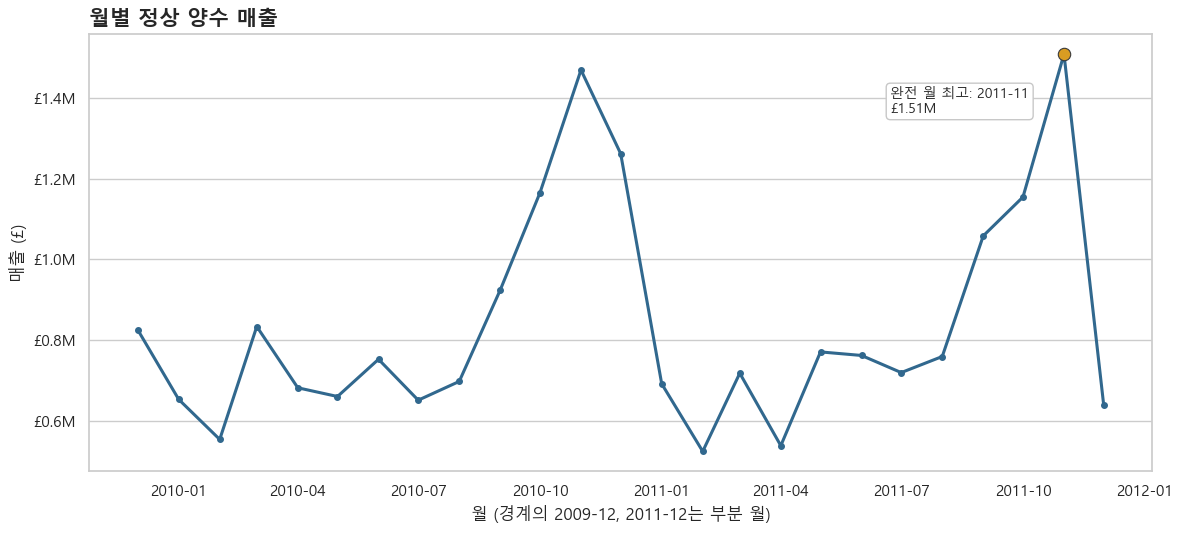

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(monthly_summary["Month"], monthly_summary["revenue"], color="#31688E", linewidth=2.2, marker="o", markersize=4)
ax.scatter(
    [peak_month["Month"]], [peak_month["revenue"]],
    color="#D89C22", edgecolor="#3A3A3A", linewidth=0.8, s=80, zorder=3,
)
ax.annotate(
    f"완전 월 최고: {peak_month['Month']:%Y-%m}\n£{peak_month['revenue']/1_000_000:.2f}M",
    (peak_month["Month"], peak_month["revenue"]),
    xytext=(-125, -42), textcoords="offset points", fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#C8C8C8"},
)
ax.set_title("월별 정상 양수 매출", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("월 (경계의 2009-12, 2011-12는 부분 월)")
ax.set_ylabel("매출 (£)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"£{value/1_000_000:.1f}M"))
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(figure_dir / "01_monthly_sales.png", dpi=160, bbox_inches="tight")
plt.show()

### 4. Country concentration

In [6]:
country_summary["revenue_share_pct"] = country_summary["revenue"] / gross_sales * 100
top_non_uk_countries = country_summary.drop(index="United Kingdom").head(10).sort_values("revenue")

display(country_summary.head(10).style.format({
    "revenue": "£{:,.0f}", "revenue_share_pct": "{:.2f}%"
}))

,revenue,orders,units,revenue_share_pct
Country,,,,
United Kingdom,"£17,870,978",37309,9383244,85.21%
EIRE,"£664,432",636,340289,3.17%
Netherlands,"£554,232",229,383977,2.64%
Germany,"£431,262",804,227983,2.06%
France,"£356,945",633,275287,1.70%
Australia,"£169,968",97,104090,0.81%
Spain,"£109,179",156,50796,0.52%
Switzerland,"£101,011",94,52884,0.48%
Sweden,"£91,904",105,88650,0.44%


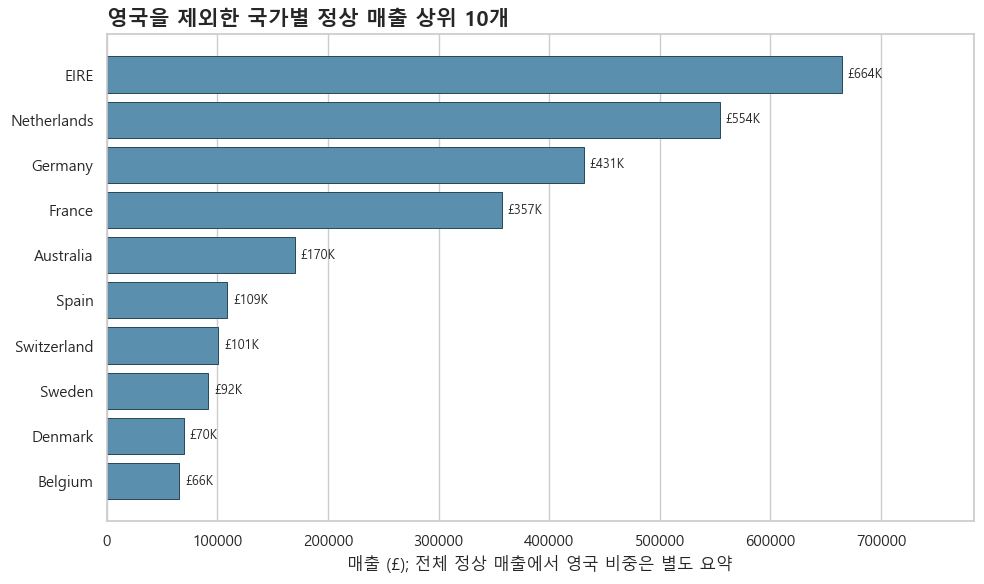

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_non_uk_countries.index,
    top_non_uk_countries["revenue"],
    color="#5A8FAD",
    edgecolor="#27485A",
    linewidth=0.7,
)
ax.bar_label(bars, labels=[f"£{value/1_000:,.0f}K" for value in top_non_uk_countries["revenue"]], padding=4, fontsize=9)
ax.set_title("영국을 제외한 국가별 정상 매출 상위 10개", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("매출 (£); 전체 정상 매출에서 영국 비중은 별도 요약")
ax.set_ylabel("")
ax.set_xlim(0, top_non_uk_countries["revenue"].max() * 1.18)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(figure_dir / "02_country_sales_ex_uk.png", dpi=160, bbox_inches="tight")
plt.show()

### 5. Product concentration

In [8]:
description_lookup = (
    sales_analysis_df.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .agg(lambda values: values.mode().iat[0] if not values.mode().empty else values.iloc[0])
)
product_summary = (
    sales_analysis_df.groupby("StockCode")
    .agg(
        revenue=("Total_Revenue", "sum"),
        units=("Quantity", "sum"),
        orders=("Invoice_Key", "nunique"),
    )
    .join(description_lookup.rename("description"))
    .sort_values("revenue", ascending=False)
)
product_summary["revenue_share_pct"] = product_summary["revenue"] / gross_sales * 100
product_summary["label"] = (
    product_summary["description"].fillna("설명 없음").str.slice(0, 38)
    + " [" + product_summary.index.astype(str) + "]"
)
top_products = product_summary.head(10).sort_values("revenue")
top_10_product_share = product_summary.head(10)["revenue"].sum() / gross_sales

display(product_summary.head(10)[["description", "revenue", "revenue_share_pct", "units", "orders"]].style.format({
    "revenue": "£{:,.0f}", "revenue_share_pct": "{:.2f}%"
}))
print(f"상위 10개 StockCode의 정상 매출 비중: {top_10_product_share:.1%}")

,description,revenue,revenue_share_pct,units,orders
StockCode,,,,,
22423,REGENCY CAKESTAND 3 TIER,"£344,563",1.64%,27577,4007
M,Manual,"£340,716",1.62%,10050,801
DOT,DOTCOM POSTAGE,"£322,657",1.54%,1436,1436
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£263,110",1.25%,96147,5479
85099B,JUMBO BAG RED RETROSPOT,"£183,455",0.87%,98349,4055
23843,"PAPER CRAFT , LITTLE BIRDIE","£168,470",0.80%,80995,1
47566,PARTY BUNTING,"£149,187",0.71%,28378,2698
84879,ASSORTED COLOUR BIRD ORNAMENT,"£132,188",0.63%,81809,2867
POST,POSTAGE,"£127,597",0.61%,5461,1886


상위 10개 StockCode의 정상 매출 비중: 10.3%


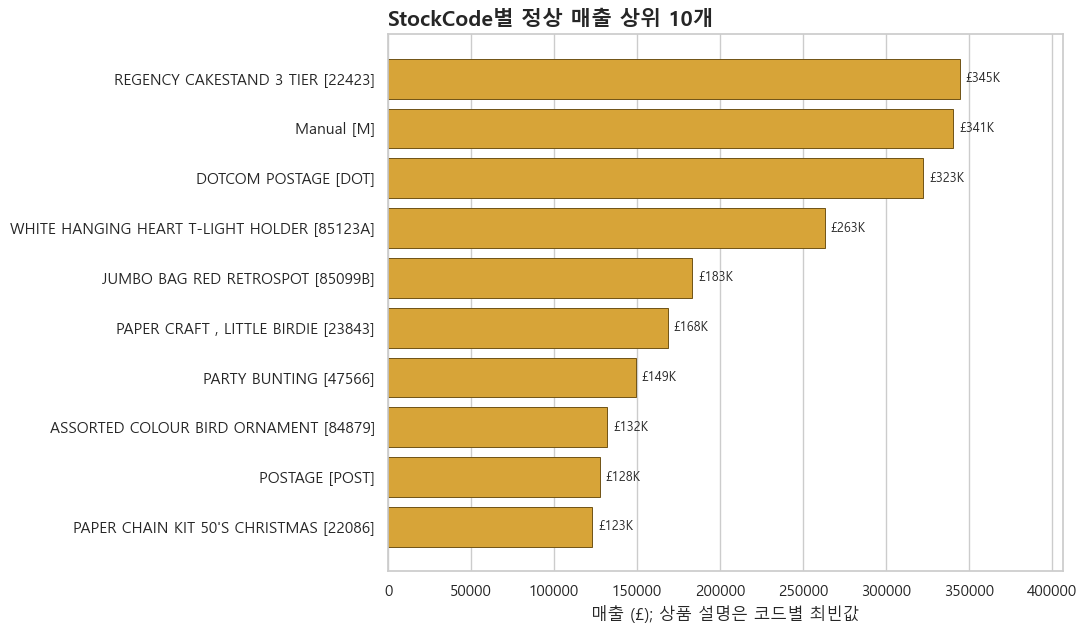

In [9]:
fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(
    top_products["label"],
    top_products["revenue"],
    color="#D7A438",
    edgecolor="#705315",
    linewidth=0.7,
)
ax.bar_label(bars, labels=[f"£{value/1_000:,.0f}K" for value in top_products["revenue"]], padding=4, fontsize=9)
ax.set_title("StockCode별 정상 매출 상위 10개", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("매출 (£); 상품 설명은 코드별 최빈값")
ax.set_ylabel("")
ax.set_xlim(0, top_products["revenue"].max() * 1.18)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(figure_dir / "03_product_sales.png", dpi=160, bbox_inches="tight")
plt.show()

### 6. Customer purchase distribution

In [10]:
customer_distribution = customer_summary[["orders", "revenue", "average_order_value"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)
display(customer_distribution.style.format({
    "orders": "{:,.1f}", "revenue": "£{:,.0f}", "average_order_value": "£{:,.0f}"
}))

repeat_summary = pd.Series({
    "identified_customers": len(customer_summary),
    "one_order_customers": customer_summary["orders"].eq(1).sum(),
    "repeat_customers": customer_summary["orders"].ge(2).sum(),
    "repeat_customer_rate_pct": repeat_customer_rate * 100,
})
repeat_summary

,orders,revenue,average_order_value
count,"5,878.0","£5,878","£5,878"
mean,6.4,"£3,019",£387
std,13.4,"£14,738","£1,214"
min,1.0,£3,£3
25%,1.0,£349,£178
50%,3.0,£899,£281
75%,7.0,"£2,307",£416
90%,14.0,"£5,595",£635
95%,21.0,"£9,535",£894
99%,46.2,"£29,730","£1,959"


identified_customers       5,878.00
one_order_customers        1,601.00
repeat_customers           4,277.00
repeat_customer_rate_pct      72.76
dtype: float64

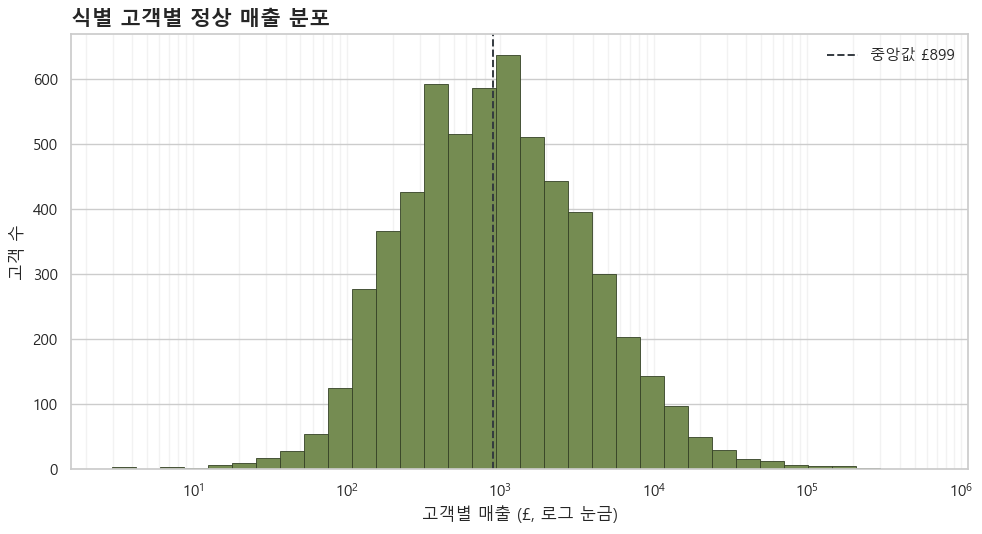

In [11]:
positive_customer_revenue = customer_summary.loc[customer_summary["revenue"].gt(0), "revenue"]
bins = np.logspace(
    np.log10(positive_customer_revenue.min()),
    np.log10(positive_customer_revenue.max()),
    35,
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    positive_customer_revenue,
    bins=bins,
    color="#758C52",
    edgecolor="#344125",
    linewidth=0.6,
)
ax.set_xscale("log")
ax.axvline(positive_customer_revenue.median(), color="#343A40", linestyle="--", linewidth=1.4, label=f"중앙값 £{positive_customer_revenue.median():,.0f}")
ax.set_title("식별 고객별 정상 매출 분포", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("고객별 매출 (£, 로그 눈금)")
ax.set_ylabel("고객 수")
ax.legend(frameon=False)
ax.grid(axis="x", which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(figure_dir / "04_customer_revenue_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### 7. Cancellations, returns, and observed net transaction value

In [12]:
return_summary = pd.Series({
    "raw_rows": len(retail_df),
    "cancelled_or_returned_rows": len(returns_df),
    "cancelled_or_returned_row_rate_pct": len(returns_df) / len(retail_df) * 100,
    "gross_positive_sales_gbp": gross_sales,
    "negative_transaction_value_gbp": negative_transaction_value,
    "negative_value_to_gross_sales_pct": negative_transaction_value / gross_sales * 100,
    "observed_net_transaction_value_gbp": observed_net_revenue,
    "flag_mismatch_rows": (
        retail_df["Is_Cancelled_Invoice"] != retail_df["Is_Negative_Quantity"]
    ).sum(),
})
return_summary

raw_rows                              1,067,371.00
cancelled_or_returned_rows               22,951.00
cancelled_or_returned_row_rate_pct            2.15
gross_positive_sales_gbp             20,972,594.57
negative_transaction_value_gbp        1,685,717.57
negative_value_to_gross_sales_pct             8.04
observed_net_transaction_value_gbp   19,287,250.57
flag_mismatch_rows                        3,458.00
dtype: float64

`negative_transaction_value`는 음수 거래금액의 절댓값 합계입니다. 취소 송장과 원거래를 직접 매칭하지 않았으므로 환불률이나 고객 귀책률로 해석하지 않습니다. 플래그 불일치 행은 조정 거래 또는 데이터 규칙 차이일 수 있어 별도 진단이 필요합니다.

## Takeaways

In [13]:
takeaway_table = pd.DataFrame({
    "finding": [
        "완전 월 최고 정상 매출",
        "영국 정상 매출 비중",
        "상위 10개 StockCode 매출 비중",
        "식별 고객 재구매 비중",
        "음수 거래금액 / 정상 양수 매출",
    ],
    "observed_value": [
        f"{peak_month['Month']:%Y-%m}: £{peak_month['revenue']:,.0f}",
        f"{uk_revenue_share:.1%}",
        f"{top_10_product_share:.1%}",
        f"{repeat_customer_rate:.1%}",
        f"{negative_transaction_value / gross_sales:.1%}",
    ],
    "next_question": [
        "계절성과 연도 차이가 반복되는가?",
        "영국 제외 시장의 규모와 구매 구조가 어떻게 다른가?",
        "집중도가 소수 주문·대량 주문에 의해 좌우되는가?",
        "신규 코호트별 재구매 유지 패턴이 다른가?",
        "취소·반품이 특정 고객·상품에 집중되는가?",
    ],
})
display(takeaway_table)

print("다음 단계: 통계 분석에서 월별 차이, 고객·상품 집중도, 취소·반품 집중을 검정합니다.")

,finding,observed_value,next_question
0,완전 월 최고 정상 매출,"2011-11: £1,509,496",계절성과 연도 차이가 반복되는가?
1,영국 정상 매출 비중,85.2%,영국 제외 시장의 규모와 구매 구조가 어떻게 다른가?
2,상위 10개 StockCode 매출 비중,10.3%,집중도가 소수 주문·대량 주문에 의해 좌우되는가?
3,식별 고객 재구매 비중,72.8%,신규 코호트별 재구매 유지 패턴이 다른가?
4,음수 거래금액 / 정상 양수 매출,8.0%,취소·반품이 특정 고객·상품에 집중되는가?


다음 단계: 통계 분석에서 월별 차이, 고객·상품 집중도, 취소·반품 집중을 검정합니다.


### Interpretation boundary

- 이 결과는 2009-12-01~2011-12-09의 해외 온라인 소매 거래 패턴이며 현재 시장의 크기나 고객 행동으로 일반화하지 않습니다.
- 국가 필드는 거래 기록상의 국가이며 고객의 국적을 의미하지 않습니다.
- 반복 구매는 관측 기간 안에서 서로 다른 송장 키가 2개 이상인 경우이며, 관측 이전·이후 활동은 알 수 없습니다.
- 다음 단계에서는 기술통계에서 관찰된 차이를 통계적으로 점검한 뒤 KPI와 RFM 세분화 기준을 확정합니다.